# GitHub Repository Analysis

**Dataset:** 500 most-starred public repositories | 13 features


## Imports & Global Style

In [1]:
import numpy as np
import pandas as pd
from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.stats import linregress, gaussian_kde
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
    'figure.dpi'        : 130,
    'savefig.bbox'      : 'tight',
    'axes.titlepad'     : 14,
})

PALETTE = ['#4361EE','#F72585','#4CC9F0','#7209B7','#3A0CA3',
           '#F3722C','#90BE6D','#43AA8B','#577590','#277DA1']
ACCENT  = '#4361EE'
BG      = '#F8F9FF'
print('Libraries loaded')

Libraries loaded


## 1 · Data Loading
Dataset collected via the **GitHub REST API** (`/search/repositories`), querying repositories sorted by star count.
Each row is one public repository with 13 attributes.

In [2]:
df = pd.read_csv('github_repos_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (500, 13)


,repo_name,owner,language,stars,forks,watchers,open_issues,created_at,updated_at,contributors,topics,description,repo_url
0,build-your-own-x,codecrafters-io,Markdown,490187,46298,490187,465,2018-05-09T12:03:18Z,2026-04-14T13:22:34Z,140.0,"awesome-list,free,programming,tutorial-code,tu...",Master programming by recreating your favorite...,https://github.com/codecrafters-io/build-your-...
1,awesome,sindresorhus,NaN,455170,34218,455170,62,2014-07-11T13:42:37Z,2026-04-14T13:21:45Z,673.0,"awesome,awesome-list,lists,resources,unicorns",😎 Awesome lists about all kinds of interesting...,https://github.com/sindresorhus/awesome
2,freeCodeCamp,freeCodeCamp,TypeScript,442860,44281,442860,206,2014-12-24T17:49:19Z,2026-04-14T13:21:23Z,6434.0,"careers,certification,community,curriculum,d3,...",freeCodeCamp.org's open-source codebase and cu...,https://github.com/freeCodeCamp/freeCodeCamp
3,public-apis,public-apis,Python,421678,45926,421678,1242,2016-03-20T23:49:42Z,2026-04-14T13:21:24Z,1380.0,"api,apis,dataset,development,free,list,lists,o...",A collective list of free APIs,https://github.com/public-apis/public-apis
4,free-programming-books,EbookFoundation,Python,385521,66108,385521,79,2013-10-11T06:50:37Z,2026-04-14T13:21:21Z,3483.0,"books,education,hacktoberfest,list,resource",:books: Freely available programming books,https://github.com/EbookFoundation/free-progra...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   repo_name     500 non-null    object 
 1   owner         500 non-null    object 
 2   language      441 non-null    object 
 3   stars         500 non-null    int64  
 4   forks         500 non-null    int64  
 5   watchers      500 non-null    int64  
 6   open_issues   500 non-null    int64  
 7   created_at    500 non-null    object 
 8   updated_at    500 non-null    object 
 9   contributors  499 non-null    float64
 10  topics        429 non-null    object 
 11  description   498 non-null    object 
 12  repo_url      500 non-null    object 
dtypes: float64(1), int64(4), object(8)
memory usage: 50.9+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
stars,500.0,83908.026000,58862.619784,44587.0,52286.5,64794.0,88583.25,490187.0
forks,500.0,13590.116000,14285.734802,1246.0,5503.0,9092.5,15365.25,107998.0
watchers,500.0,83908.026000,58862.619784,44587.0,52286.5,64794.0,88583.25,490187.0
open_issues,500.0,1075.010000,2732.181377,0.0,68.0,283.0,862.75,33154.0
contributors,499.0,796.222445,1662.974963,1.0,90.5,321.0,812.00,21986.0


## 2 · Data Cleaning & Preparation
Steps:
- Convert `created_at` / `updated_at` to datetime
- Fill missing `language` with `Unknown`
- Drop duplicates
- Engineer: `repo_age`, `created_year`, `fork_ratio`, `engagement`

In [5]:
missing = df.isnull().sum()
pd.DataFrame({'Missing Count': missing, 'Missing %': (missing/len(df)*100).round(2)}).query('`Missing Count` > 0')

,Missing Count,Missing %
language,59,11.8
contributors,1,0.2
topics,71,14.2
description,2,0.4


In [6]:
df['created_at'] = pd.to_datetime(df['created_at'], utc=True).dt.tz_localize(None)
df['updated_at'] = pd.to_datetime(df['updated_at'], utc=True).dt.tz_localize(None)
df['language']   = df['language'].fillna('Unknown')
before = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed: {before - len(df)}')
df['repo_age']     = (pd.Timestamp.now() - df['created_at']).dt.days / 365
df['created_year'] = df['created_at'].dt.year
df['fork_ratio']   = df['forks'] / df['stars']
df['engagement']   = df['stars'] + df['forks']*2 + df['watchers']
print(f'Final shape: {df.shape}')
df.head(3)

Duplicates removed: 0
Final shape: (500, 17)


,repo_name,owner,language,stars,forks,watchers,open_issues,created_at,updated_at,contributors,topics,description,repo_url,repo_age,created_year,fork_ratio,engagement
0,build-your-own-x,codecrafters-io,Markdown,490187,46298,490187,465,2018-05-09 12:03:18,2026-04-14 13:22:34,140.0,"awesome-list,free,programming,tutorial-code,tu...",Master programming by recreating your favorite...,https://github.com/codecrafters-io/build-your-...,7.967123,2018,0.094450,1072970
1,awesome,sindresorhus,Unknown,455170,34218,455170,62,2014-07-11 13:42:37,2026-04-14 13:21:45,673.0,"awesome,awesome-list,lists,resources,unicorns",😎 Awesome lists about all kinds of interesting...,https://github.com/sindresorhus/awesome,11.797260,2014,0.075176,978776
2,freeCodeCamp,freeCodeCamp,TypeScript,442860,44281,442860,206,2014-12-24 17:49:19,2026-04-14 13:21:23,6434.0,"careers,certification,community,curriculum,d3,...",freeCodeCamp.org's open-source codebase and cu...,https://github.com/freeCodeCamp/freeCodeCamp,11.339726,2014,0.099989,974282


## 3 · Exploratory Data Analysis

### 3.1 · Statistical Summary

In [7]:
num_cols = ['stars','forks','watchers','open_issues','contributors','repo_age','fork_ratio']
df[num_cols].agg(['mean','median','std','skew']).T.round(2)

,mean,median,std,skew
stars,83908.03,64794.00,58862.62,3.59
forks,13590.12,9092.50,14285.73,2.91
watchers,83908.03,64794.00,58862.62,3.59
open_issues,1075.01,283.00,2732.18,6.25
contributors,796.22,321.00,1662.97,7.30
repo_age,8.12,8.51,4.43,-0.07
fork_ratio,0.16,0.13,0.14,5.22


**Key observations:**
- `stars` and `forks` are **heavily right-skewed** — classic power-law distribution.
- `contributors` has extreme variance: from 1 to 21,986.
- `fork_ratio` averages ~0.16 — 16% of star-givers also fork the repo.
- `repo_age` spans from < 1 year to 18+ years.

### 3.2 · Q1 — How Are GitHub Stars Distributed?
Stars follow a **log-normal / power-law** distribution. Most repos cluster at 44K–80K stars,
while a small elite exceeds 200K. Python and TypeScript repos tend to have higher medians.

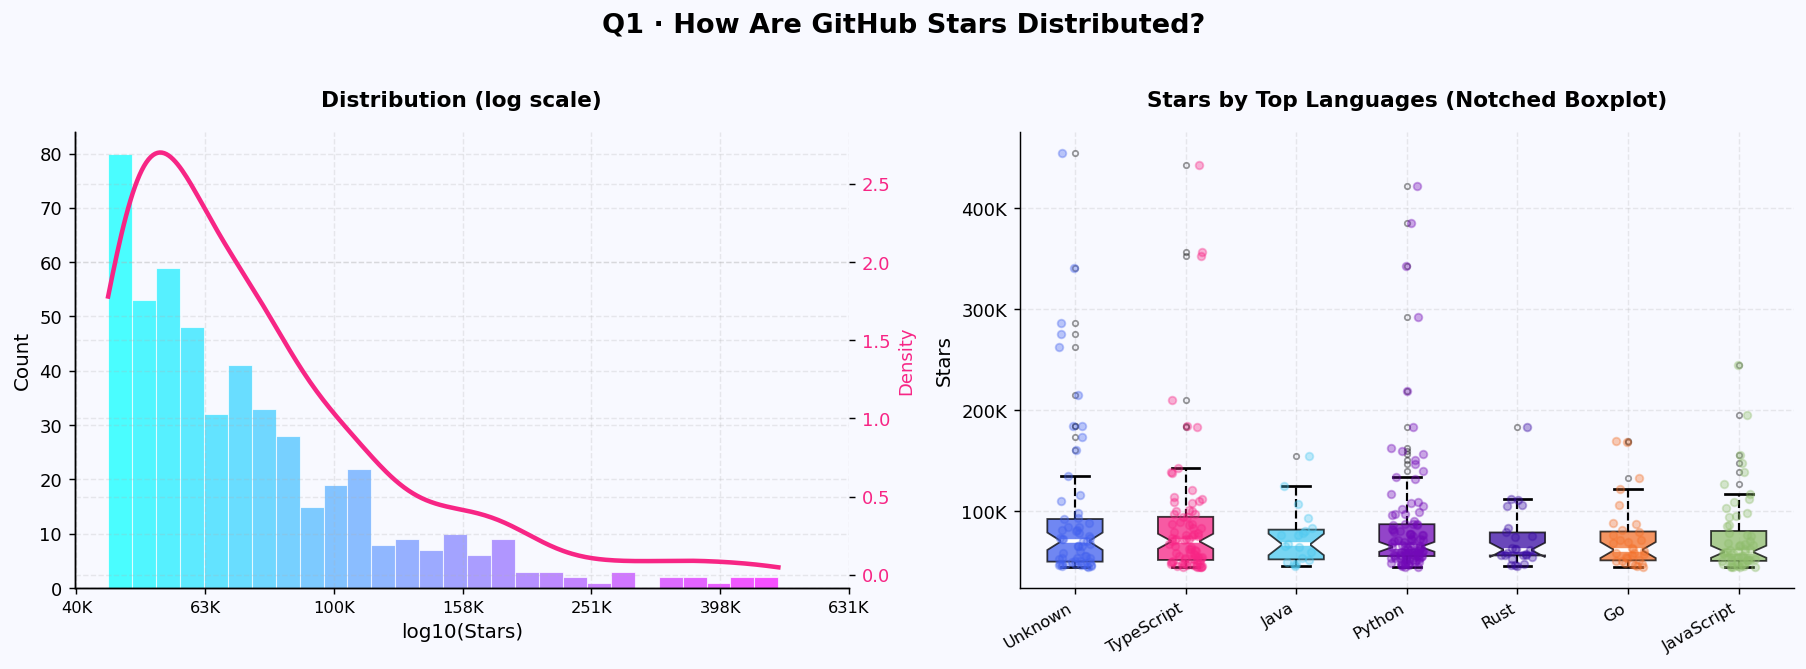

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('Q1 · How Are GitHub Stars Distributed?', fontsize=15, fontweight='bold', x=0.5, y=1.02)

# Left — Log histogram + KDE
ax = axes[0]; ax.set_facecolor(BG)
log_stars = np.log10(df['stars'])
n, bins, patches = ax.hist(log_stars, bins=28, color=ACCENT, alpha=0.7, edgecolor='white', linewidth=0.6)
for i, patch in enumerate(patches):
    patch.set_facecolor(plt.cm.cool(i / len(patches)))
kde = gaussian_kde(log_stars, bw_method=0.3)
xkde = np.linspace(log_stars.min(), log_stars.max(), 300)
ax2 = ax.twinx()
ax2.plot(xkde, kde(xkde), color='#F72585', lw=2.5)
ax2.set_ylabel('Density', color='#F72585', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#F72585')
ax2.spines['top'].set_visible(False)
ax.set_xlabel('log10(Stars)', fontsize=11); ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution (log scale)', fontsize=12, fontweight='bold')
ticks = [4.6, 4.8, 5.0, 5.2, 5.4, 5.6, 5.8]
ax.set_xticks(ticks)
ax.set_xticklabels([f'{10**t/1000:.0f}K' for t in ticks], fontsize=9)

# Right — Notched boxplot + strip
ax = axes[1]; ax.set_facecolor(BG)
top_langs = df['language'].value_counts().head(7).index.tolist()
sub = df[df['language'].isin(top_langs)].copy()
order = sub.groupby('language')['stars'].median().sort_values(ascending=False).index
colors_box = PALETTE[:len(order)]
bp = ax.boxplot(
    [sub[sub['language']==l]['stars'].values for l in order],
    patch_artist=True, notch=True, vert=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2, linestyle='--'),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for i, lang in enumerate(order, 1):
    vals = sub[sub['language']==lang]['stars'].values
    jitter = np.random.uniform(-0.15, 0.15, size=len(vals))
    ax.scatter(i+jitter, vals, alpha=0.35, s=18, color=colors_box[i-1], zorder=3)
ax.set_xticks(range(1, len(order)+1))
ax.set_xticklabels(order, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Stars', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_title('Stars by Top Languages (Notched Boxplot)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

#### Interpretation of Distribution Plot (Left)

The distribution of stars (on a log scale) is highly right-skewed, indicating that:

* A large number of repositories have relatively low star counts
* Only a small number of repositories achieve extremely high popularity
* The density curve confirms a long tail distribution, where a few repositories dominate in terms of stars

#### Interpretation of Boxplot (Right)

The boxplot compares star distributions across top programming languages.

Key observations:
* Python and TypeScript repositories show:
  * Higher median stars
  * Wider spread → indicating both average and highly popular repos
* Java and Go repositories:
  * More compact distributions
  * Lower variability → more consistent but fewer extreme outliers
* JavaScript:
  * Shows strong upper outliers → some extremely popular repositories
* Unknown category:
  * Contains some high-star repositories, likely due to missing metadata

#### Comparative Insights
* Certain languages (like Python and TypeScript) are associated with higher overall popularity
* Languages like Java show stable but moderate popularity
* The presence of many outliers indicates that:
   - Popularity is not just language-dependent but also influenced by other factors (e.g., utility, community, innovation)

### 3.3 · Q2 — Which Languages Dominate Top Repositories?
Python leads at 21% of top repos. The diverging bar shows **Go and Rust** perform above
the global median in stars despite fewer repos — quality over quantity.

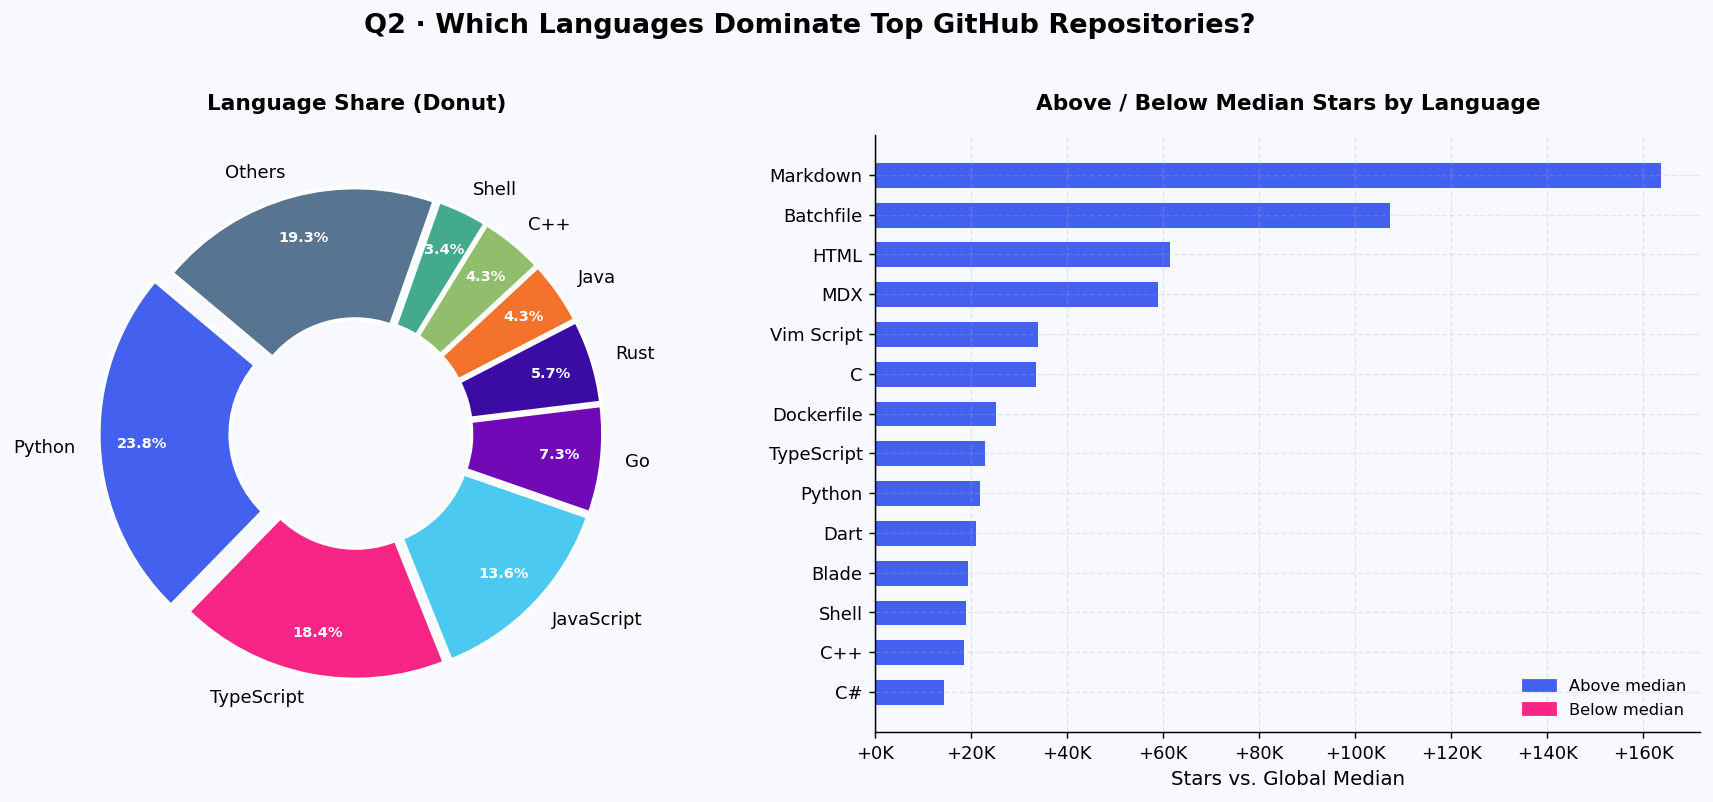

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
fig.suptitle('Q2 · Which Languages Dominate Top GitHub Repositories?', fontsize=15, fontweight='bold', y=1.02)

# Donut
ax = axes[0]; ax.set_facecolor(BG)
lang_counts = df[df['language']!='Unknown']['language'].value_counts()
top8 = lang_counts.head(8)
labels = list(top8.index) + ['Others']
sizes  = list(top8.values) + [lang_counts.iloc[8:].sum()]
explode = [0.03]*len(labels); explode[0] = 0.08
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%', startangle=140,
    colors=PALETTE[:len(labels)], explode=explode,
    pctdistance=0.82, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for t in autotexts: t.set_fontsize(8); t.set_color('white'); t.set_fontweight('bold')
ax.set_title('Language Share (Donut)', fontsize=12, fontweight='bold')

# Diverging bar
ax = axes[1]; ax.set_facecolor(BG)
global_median = df['stars'].median()
lang_avg = df[df['language']!='Unknown'].groupby('language')['stars'].mean().sort_values().tail(14)
delta = lang_avg - global_median
colors_div = [PALETTE[0] if v >= 0 else '#F72585' for v in delta]
ax.barh(delta.index, delta.values, color=colors_div, edgecolor='white', linewidth=0.5, height=0.65)
ax.axvline(0, color='black', linewidth=1.2)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:+.0f}K'))
ax.set_xlabel('Stars vs. Global Median', fontsize=11)
ax.set_title('Above / Below Median Stars by Language', fontsize=12, fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=PALETTE[0],label='Above median'),
                   mpatches.Patch(color='#F72585',label='Below median')], fontsize=9, framealpha=0)
plt.tight_layout(); plt.show()

#### Interpretation of Language Share (Donut Chart)

The donut chart shows the distribution of repositories across programming languages.

Key observations:
* Python (23.8%) has the highest share, making it the most dominant language
* TypeScript (18.4%) and JavaScript (13.6%) also hold significant portions
* Together, these three languages account for more than 50% of all repositories
* The "Others" category (~19%) indicates a long tail of less common languages

Insight:
* Modern, high-level languages like Python and TypeScript dominate the GitHub ecosystem, reflecting their widespread adoption in fields such as data science, web development, and automation.

#### Interpretation of Above/Below Median Stars (Right Chart)

This chart compares how different languages perform relative to the global median stars.

Key observations:
* Markdown and Batchfile show extremely high values above the median
   * Likely due to their use in highly popular repositories (documentation-heavy or config-based projects)
* HTML and MDX also perform strongly above the median
   * Suggesting that frontend or documentation-related repositories can gain significant popularity
* Python and TypeScript, despite high representation:
   * Show moderate values above median
   * Indicating consistent but not extreme dominance
* Lower-performing languages (e.g., C#, C++, Shell):
   * Show smaller deviations from the median
   * Indicating relatively lower popularity impact

#### Comparative Insights
* There is a difference between quantity and impact:
   * Python dominates in count
   * But other languages (like Markdown, HTML) show higher relative performance
* Some languages appear frequently but don’t necessarily produce the most popular repositories
* Popularity is influenced not just by programming language but also by:
   * Project type (documentation, frameworks, tools)
   * Community usage

### 3.4 · Q3 — How Do Engagement Metrics Correlate?
- Stars ↔ Watchers: r = 1.0 (GitHub counts them identically).
- Stars ↔ Forks: r ≈ 0.7 — popular repos get forked more.
- Open Issues ↔ Contributors: moderate positive — active communities generate issues.
- Repo Age has a weak relationship with stars — newer repos can still compete.

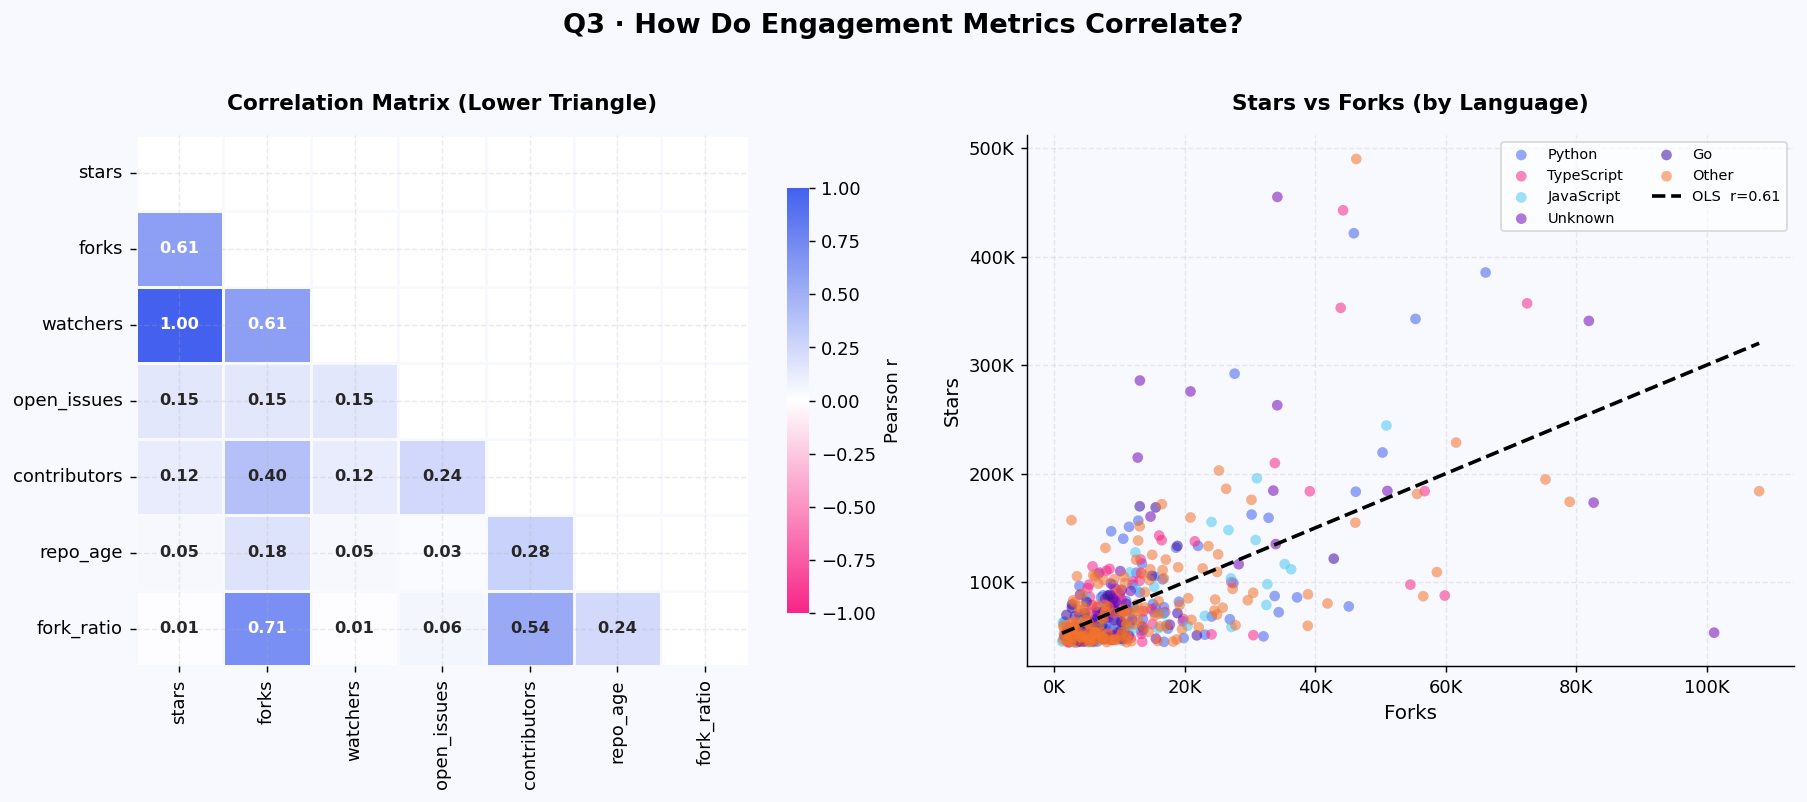

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
fig.suptitle('Q3 · How Do Engagement Metrics Correlate?', fontsize=15, fontweight='bold', y=1.02)

numeric_cols = ['stars','forks','watchers','open_issues','contributors','repo_age','fork_ratio']
corr = df[numeric_cols].corr()
ax = axes[0]
mask = np.triu(np.ones_like(corr, dtype=bool))
custom_cmap = LinearSegmentedColormap.from_list('custom_div', ['#F72585','#ffffff','#4361EE'])
sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt='.2f', cmap=custom_cmap,
            vmin=-1, vmax=1, linewidths=1.5, linecolor=BG,
            cbar_kws={'shrink':0.8,'label':'Pearson r'}, annot_kws={'size':9,'weight':'bold'})
ax.set_title('Correlation Matrix (Lower Triangle)', fontsize=12, fontweight='bold')

ax = axes[1]; ax.set_facecolor(BG)
top5_langs = df['language'].value_counts().head(5).index.tolist()
df['lang_group'] = df['language'].apply(lambda x: x if x in top5_langs else 'Other')
lang_order = top5_langs + ['Other']
color_map = dict(zip(lang_order, PALETTE[:len(lang_order)]))
for lang in lang_order:
    s = df[df['lang_group']==lang]
    ax.scatter(s['forks'], s['stars'], alpha=0.55, s=35, color=color_map[lang], label=lang, edgecolors='none')
slope, intercept, r, p, _ = linregress(df['forks'], df['stars'])
xline = np.linspace(df['forks'].min(), df['forks'].max(), 200)
ax.plot(xline, slope*xline+intercept, 'k--', lw=2, label=f'OLS  r={r:.2f}')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_xlabel('Forks', fontsize=11); ax.set_ylabel('Stars', fontsize=11)
ax.set_title('Stars vs Forks (by Language)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.7, ncol=2)
plt.tight_layout(); plt.show()

#### Interpretation of Correlation Matrix (Left)

The correlation matrix shows relationships between key repository metrics.

Key observations:
* Stars and Watchers (r ≈ 1.00)
    * Almost perfect correlation
    * Indicates both metrics capture nearly identical user interest
* Stars and Forks (r ≈ 0.61)
    * Strong positive correlation
    * More forks generally correspond to higher popularity
* Forks and Contributors (r ≈ 0.40)
    * Moderate relationship
    * More collaboration tends to increase repository duplication
* Fork Ratio and Forks (r ≈ 0.71)
    * Strong relationship
    * Suggests fork ratio is a derived metric reflecting fork activity
* Open Issues (r ≈ 0.15 with stars)
    * Weak correlation
    * Issue count does not strongly influence popularity
* Repository Age (very low correlations)
    * Indicates age alone is not a strong predictor of stars

#### Interpretation of Stars vs Forks Scatter Plot (Right)

Key observations:
* A clear upward trend is visible
* The regression line (r ≈ 0.61) confirms a moderate-to-strong positive relationship
* Most repositories cluster in:
    * Low forks (0–20K) 
    * Moderate stars (50K–150K)
* A few repositories appear as outliers:
    * Very high stars despite moderate forks
    * Indicates exceptional popularity
* Language coloring shows:
    * No single language dominates the relationship entirely
    * Pattern holds across multiple languages

#### Comparative Insights
* Forks act as a strong indicator of community engagement
* Watchers may be redundant due to near-perfect correlation with stars
* Contributors have moderate influence → useful for modeling
* Open issues and repo age contribute less to predicting popularity

### 3.5 · Q4 — How Has Open-Source Growth Evolved Over Time?
- Repo creation peaked in **2013–2016**, dipped mid-2020s, then rebounded in **2023–2025** driven by AI/LLM projects.
- Repos from **2014** show the highest average stars — older repos had more time to accumulate them.
- **Python and TypeScript** have overtaken JavaScript in recent years.

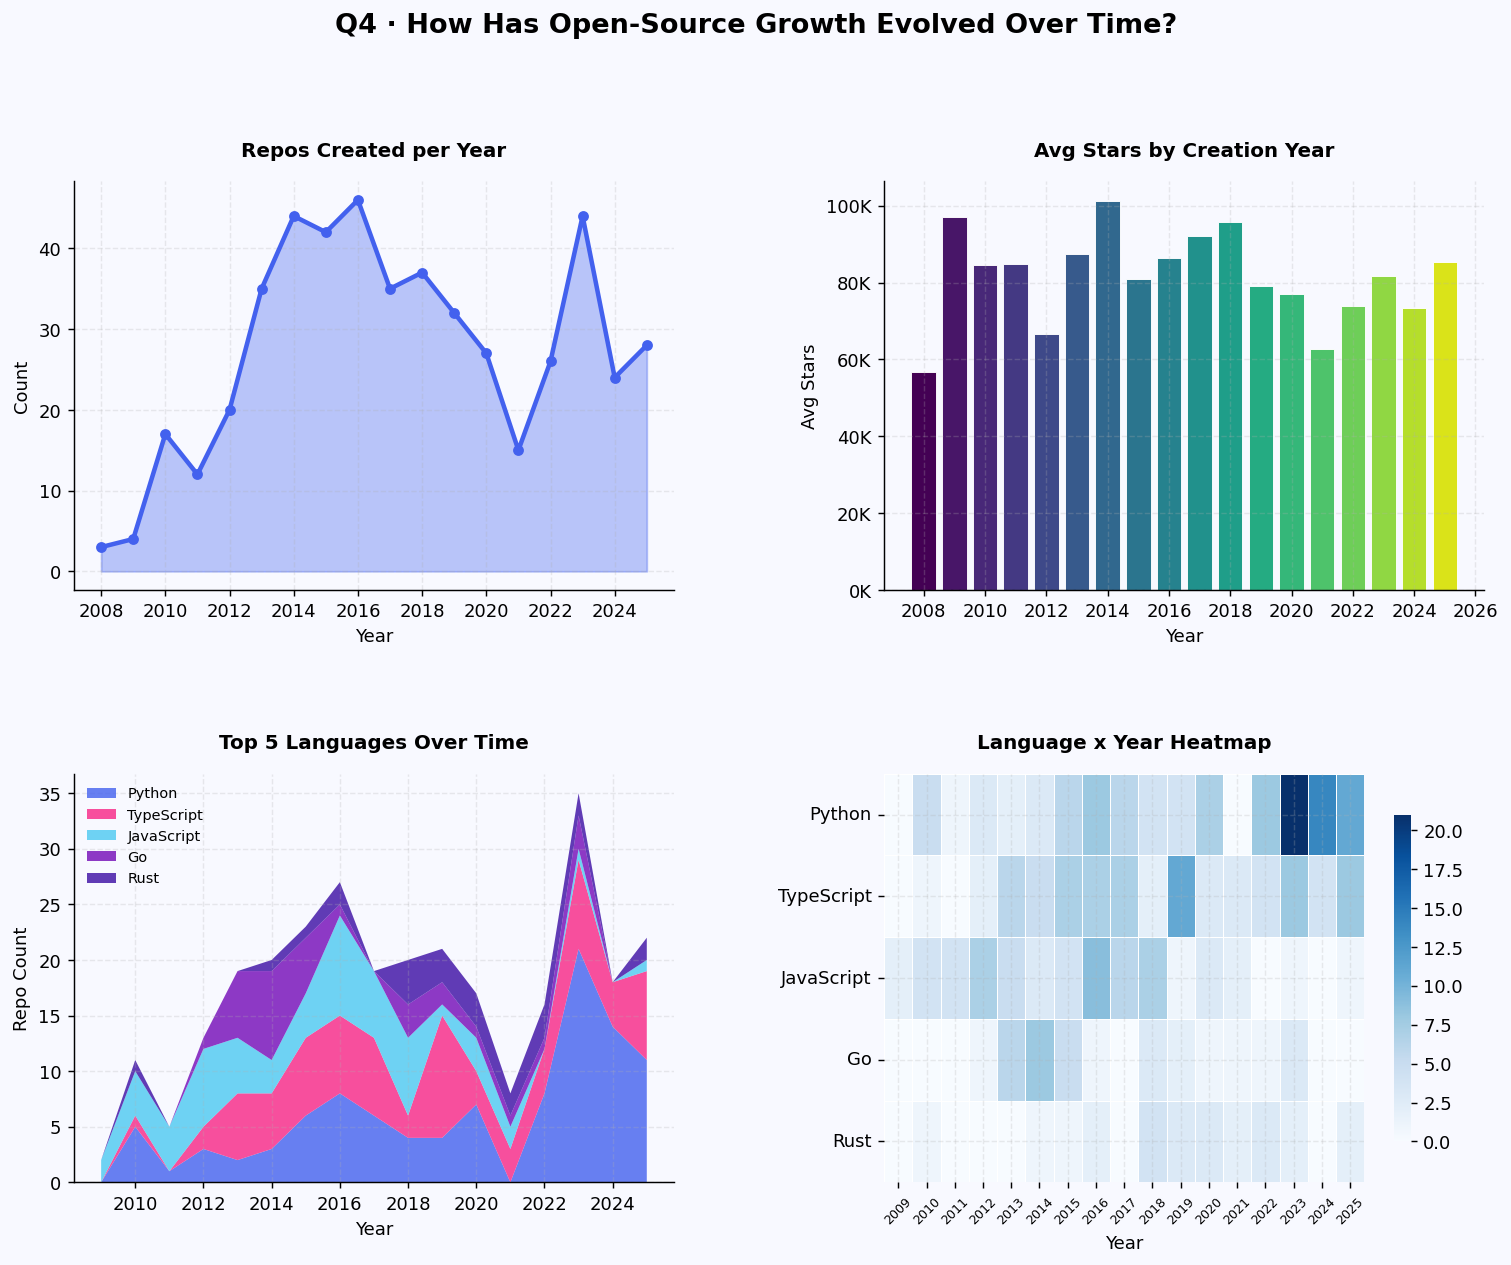

In [11]:
fig = plt.figure(figsize=(14, 10), facecolor=BG)
fig.suptitle('Q4 · How Has Open-Source Growth Evolved Over Time?', fontsize=15, fontweight='bold', y=1.01)
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
yearly = df.groupby('created_year').agg(count=('repo_name','count'), avg_stars=('stars','mean')).reset_index()
yearly = yearly[yearly['created_year'] <= 2025]

ax1 = fig.add_subplot(gs[0,0]); ax1.set_facecolor(BG)
ax1.fill_between(yearly['created_year'], yearly['count'], alpha=0.35, color=ACCENT)
ax1.plot(yearly['created_year'], yearly['count'], color=ACCENT, lw=2.5, marker='o', markersize=5)
ax1.set_title('Repos Created per Year', fontsize=11, fontweight='bold')
ax1.set_xlabel('Year'); ax1.set_ylabel('Count')
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax2 = fig.add_subplot(gs[0,1]); ax2.set_facecolor(BG)
ax2.bar(yearly['created_year'], yearly['avg_stars'],
        color=[plt.cm.viridis(i/len(yearly)) for i in range(len(yearly))],
        edgecolor='white', linewidth=0.5)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax2.set_title('Avg Stars by Creation Year', fontsize=11, fontweight='bold')
ax2.set_xlabel('Year'); ax2.set_ylabel('Avg Stars')
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax3 = fig.add_subplot(gs[1,0]); ax3.set_facecolor(BG)
top5 = df[df['language']!='Unknown']['language'].value_counts().head(5).index.tolist()
lang_year = (df[df['language'].isin(top5)].groupby(['created_year','language'])
             .size().unstack(fill_value=0).reindex(columns=top5))
lang_year = lang_year[lang_year.index <= 2025]
ax3.stackplot(lang_year.index, lang_year.T.values, labels=top5, colors=PALETTE[:5], alpha=0.8)
ax3.legend(loc='upper left', fontsize=8, framealpha=0)
ax3.set_title('Top 5 Languages Over Time', fontsize=11, fontweight='bold')
ax3.set_xlabel('Year'); ax3.set_ylabel('Repo Count')

ax4 = fig.add_subplot(gs[1,1])
pivot = (df[df['language'].isin(top5)&(df['created_year']<=2025)]
         .groupby(['created_year','language']).size().unstack(fill_value=0)[top5])
sns.heatmap(pivot.T, ax=ax4, cmap='Blues', linewidths=0.4, linecolor='white',
            cbar_kws={'shrink':0.8})
ax4.set_title('Language x Year Heatmap', fontsize=11, fontweight='bold')
ax4.set_xlabel('Year'); ax4.set_ylabel('')
ax4.tick_params(axis='x', rotation=45, labelsize=7)
plt.tight_layout(); plt.show()

#### Interpretation of Repositories Created per Year (Top Left)
Key observations:
* There is a clear growth trend from 2008 to around 2015–2016
* Peak repository creation occurs around 2015–2016
* After this peak:
    * A slight decline and fluctuation is observed
* A secondary rise appears around 2022–2023

Insight:
* The growth of repositories on GitHub shows an initial expansion phase followed by stabilization, indicating a maturing open-source ecosystem.

#### Interpretation of Average Stars by Year (Top Right)
Key observations:
* Early years (2009–2012):
    * Moderate average stars
* Around 2014–2016:
    * Peak in average stars (~100K)
* Later years:
    * Slight decline, but still relatively high

Insight:
* Repositories created during the mid-2010s tend to have higher average popularity, possibly due to increased platform adoption and high-impact projects during that period.

#### Interpretation of Language Trends Over Time (Bottom Left)
Key observations:
* Python shows strong growth, especially after 2020
* TypeScript increases steadily, reflecting modern web development trends
* JavaScript remains consistently present
* Go and Rust show gradual emergence, indicating adoption of newer technologies

Insight:
* The data highlights a shift toward modern, high-level and system-efficient languages, with Python and TypeScript gaining dominance in recent years.

#### Interpretation of Language × Year Heatmap (Bottom Right)
Key observations:
* Python dominates recent years, especially after 2021
* TypeScript shows spikes around 2018–2020
* JavaScript remains steady but less dominant over time
* Go and Rust show niche but growing presence

Insight:
* The heatmap reinforces the trend that newer technologies are gaining traction, while traditional languages maintain consistent but relatively stable usage.

#### Combined Insights
* Open-source growth experienced:
    * Rapid expansion phase (2008–2016)
    * Stabilization phase (post-2016)
* Popularity (stars) peaked during the mid-growth phase
* Language trends show:
    * Shift toward Python and TypeScript
    * Emergence of modern systems languages (Go, Rust)

### 3.6 · Q5 — What Topics Define Popular Open-Source Projects?
- **AI, LLM, ChatGPT, openai** are the fastest-rising topics — entirely 2022–2025 driven.
- **hacktoberfest** appears in 43 repos reflecting contribution culture.
- Classic topics like `javascript`, `python`, `react` remain dominant by volume.

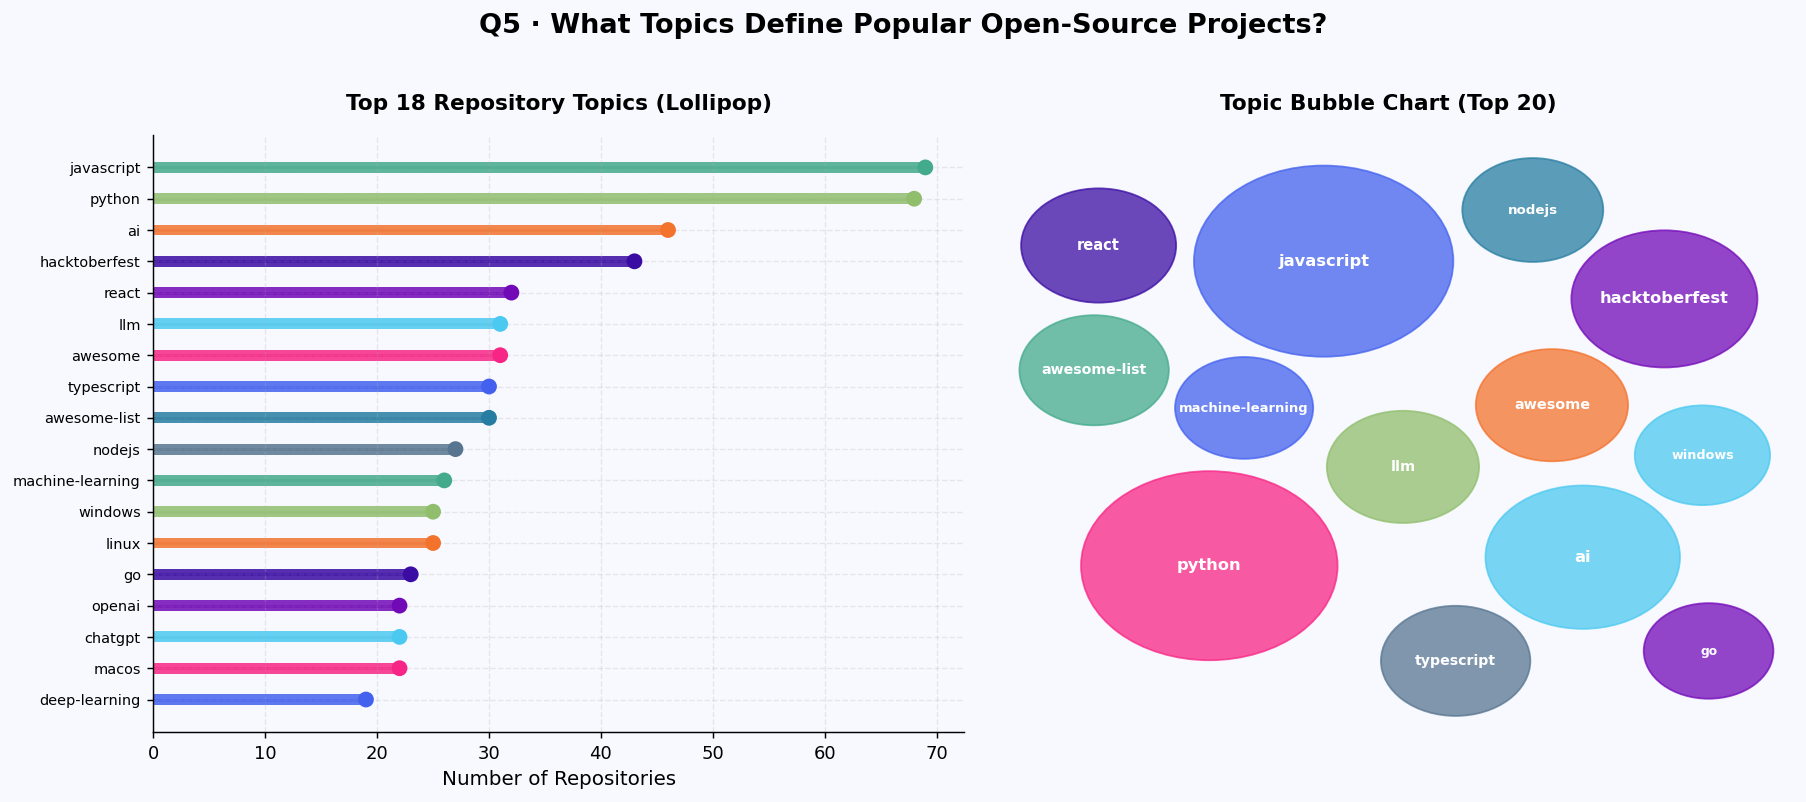

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
fig.suptitle('Q5 · What Topics Define Popular Open-Source Projects?', fontsize=15, fontweight='bold', y=1.02)

all_topics = []
for t in df['topics'].dropna():
    all_topics.extend([x.strip() for x in t.split(',')])
topic_counts = Counter(all_topics)
top_topics = pd.Series(dict(topic_counts.most_common(18))).sort_values()

ax = axes[0]; ax.set_facecolor(BG)
colors_lol = [PALETTE[i % len(PALETTE)] for i in range(len(top_topics))]
ax.barh(top_topics.index, top_topics.values, color=colors_lol, height=0.35, alpha=0.85, edgecolor='none')
ax.scatter(top_topics.values, top_topics.index, color=colors_lol, s=60, zorder=5)
for i,(label,val) in enumerate(top_topics.items()):
    ax.hlines(label, 0, val, color=colors_lol[i], linewidth=1.5, alpha=0.5)
ax.set_xlabel('Number of Repositories', fontsize=11)
ax.set_title('Top 18 Repository Topics (Lollipop)', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

ax = axes[1]; ax.set_facecolor(BG)
ax.set_xlim(0,100); ax.set_ylim(0,100); ax.axis('off')
ax.set_title('Topic Bubble Chart (Top 20)', fontsize=12, fontweight='bold')
top20 = dict(topic_counts.most_common(20))
max_count = max(top20.values())
np.random.seed(42)
placed = []
for idx,(topic,count) in enumerate(top20.items()):
    r = 4 + (count/max_count)*12
    color = PALETTE[idx % len(PALETTE)]
    for _ in range(500):
        cx = np.random.uniform(r+2, 100-r-2)
        cy = np.random.uniform(r+2, 100-r-2)
        ok = all(np.hypot(cx-px, cy-py) > r+pr+1.5 for px,py,pr in placed)
        if ok:
            placed.append((cx,cy,r))
            ax.add_patch(plt.Circle((cx,cy), r, color=color, alpha=0.75))
            ax.text(cx, cy, topic, ha='center', va='center',
                    fontsize=max(5,min(9,r*0.85)), fontweight='bold', color='white')
            break
plt.tight_layout(); plt.show()

#### Interpretation of Top Repository Topics (Left – Lollipop Chart)
Key observations:
* JavaScript (~70 repos) and Python (~68 repos) dominate the topic space
* Hacktoberfest and AI (~45 repos each) show strong presence
* React (~33 repos) and TypeScript (~30 repos) are also highly represented
* Emerging topics include:
    * LLM (Large Language Models)
    * Machine Learning
    * ChatGPT / OpenAI-related tags

Insight:
* The dominance of JavaScript and Python topics reflects their widespread use in modern development, while the strong presence of AI-related tags highlights the growing influence of artificial intelligence in open-source projects.

#### Interpretation of Topic Bubble Chart (Right)
Key observations:
* JavaScript and Python appear as the largest bubbles
* Indicating both high frequency and strong influence
* AI and React:
    * Significant size → high relevance in modern repositories
* Machine Learning and LLM:
    * Moderate size → emerging but impactful
* Hacktoberfest:
    * Large presence → reflects community-driven contributions
* System-level topics (Linux, Windows, Node.js):
    * Smaller but still relevant

#### Comparative Insights
* There is a clear dominance of:
    * Web development ecosystem (JavaScript, React, Node.js)
    * Data/AI ecosystem (Python, AI, Machine Learning, LLMs)
* The presence of tags like:
    * ChatGPT, OpenAI, LLM
        → Indicates a recent trend toward generative AI projects
* Community-driven initiatives like:
    * Hacktoberfest
        → Show the importance of collaborative contribution events

### 3.7 · Q6 — Does Repository Age Predict Popularity?
- Weak positive regression (r ≈ 0.1–0.2) — older repos have had more time but it is not decisive.
- Violin plot shows **2–5 year** repos have the widest spread — growth era matters more than raw age.
- Very new repos (< 2 yrs) already at 44K+ stars — AI projects can go viral almost instantly.

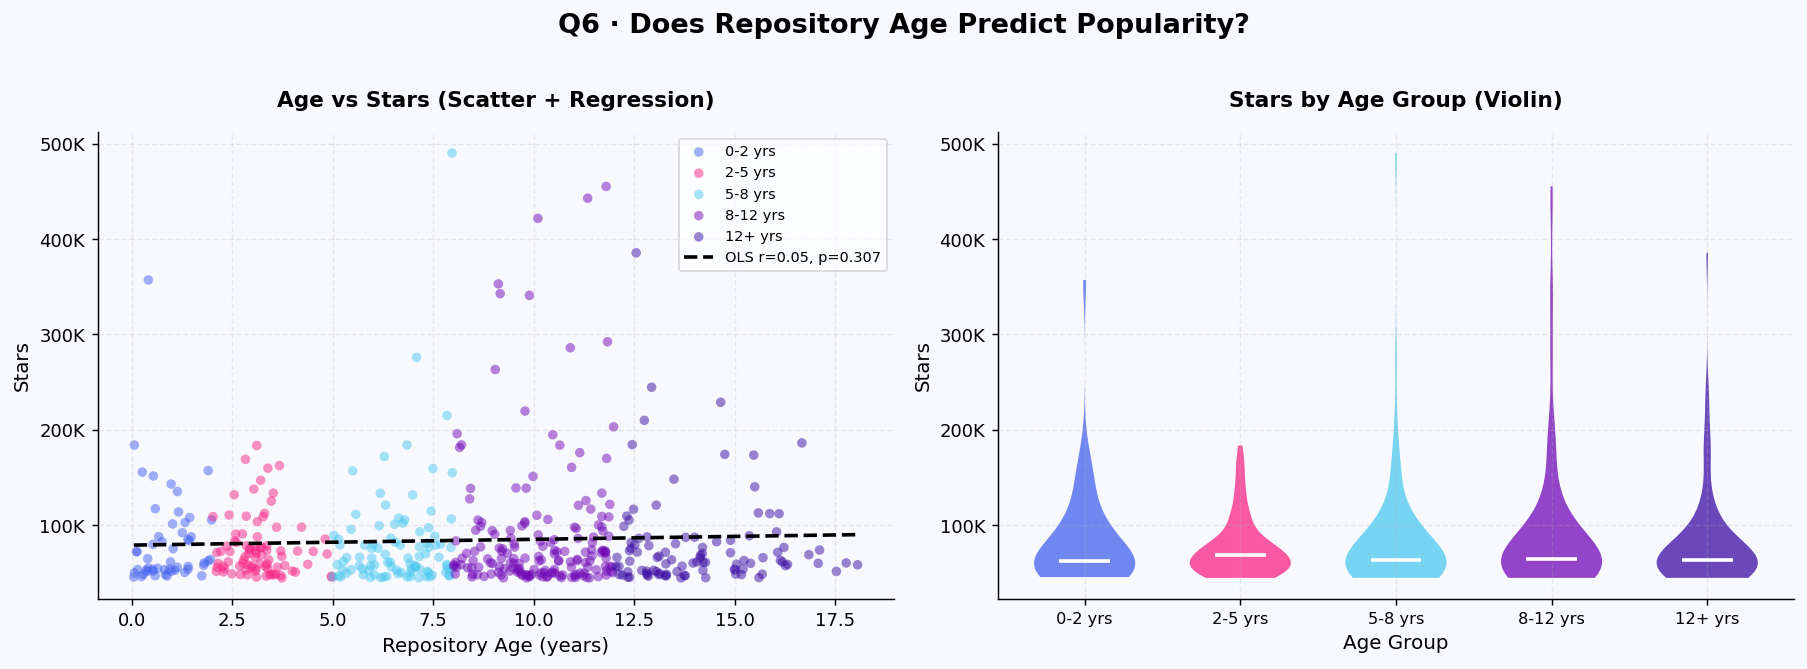

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('Q6 · Does Repository Age Predict Popularity?', fontsize=15, fontweight='bold', y=1.02)

bins = [0,2,5,8,12,20]
labels_age = ['0-2 yrs','2-5 yrs','5-8 yrs','8-12 yrs','12+ yrs']
df['age_bin'] = pd.cut(df['repo_age'], bins=bins, labels=labels_age)
pal_age = {l: PALETTE[i] for i,l in enumerate(labels_age)}

ax = axes[0]; ax.set_facecolor(BG)
for grp,sub in df.groupby('age_bin', observed=True):
    ax.scatter(sub['repo_age'], sub['stars'], alpha=0.5, s=28,
               color=pal_age[grp], label=grp, edgecolors='none')
slope,intercept,r,p,_ = linregress(df['repo_age'], df['stars'])
xr = np.linspace(df['repo_age'].min(), df['repo_age'].max(), 200)
ax.plot(xr, slope*xr+intercept, 'k--', lw=2, label=f'OLS r={r:.2f}, p={p:.3f}')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.set_xlabel('Repository Age (years)', fontsize=11); ax.set_ylabel('Stars', fontsize=11)
ax.set_title('Age vs Stars (Scatter + Regression)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.7)

ax = axes[1]; ax.set_facecolor(BG)
age_data = [df[df['age_bin']==l]['stars'].dropna().values for l in labels_age]
vp = ax.violinplot(age_data, positions=range(len(labels_age)),
                   showmedians=True, showextrema=False, widths=0.65)
for i,body in enumerate(vp['bodies']): body.set_facecolor(PALETTE[i]); body.set_alpha(0.75)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(labels_age)))
ax.set_xticklabels(labels_age, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.set_xlabel('Age Group', fontsize=11); ax.set_ylabel('Stars', fontsize=11)
ax.set_title('Stars by Age Group (Violin)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

#### Interpretation of Age vs Stars (Left)
Key observations:
* The regression line is almost flat (r ≈ 0.05)
* Very weak relationship between:
    * Repository age
    * Number of stars
* High-star repositories exist across:
    * Both new and old repositories

#### Interpretation of Violin Plot (Right)
Key observations:
* All age groups show similar median star values
* Wide spread in each group → high variability
* No clear trend of:
    * “Older = more stars” or
    * “Newer = more popular”

Insight:
* Repository age has minimal impact on popularity, indicating that success on GitHub is driven more by relevance and community engagement than by longevity.

### 3.8 · Q7 — Who Are the Top Repositories?
- **build-your-own-x** leads with 490K stars — a documentation repo, not a framework.
- Radar shows **freeCodeCamp** dominates in contributors (6,000+) and open issues.
- Most top-10 repos are **educational/resource** repos — the community values learning material.

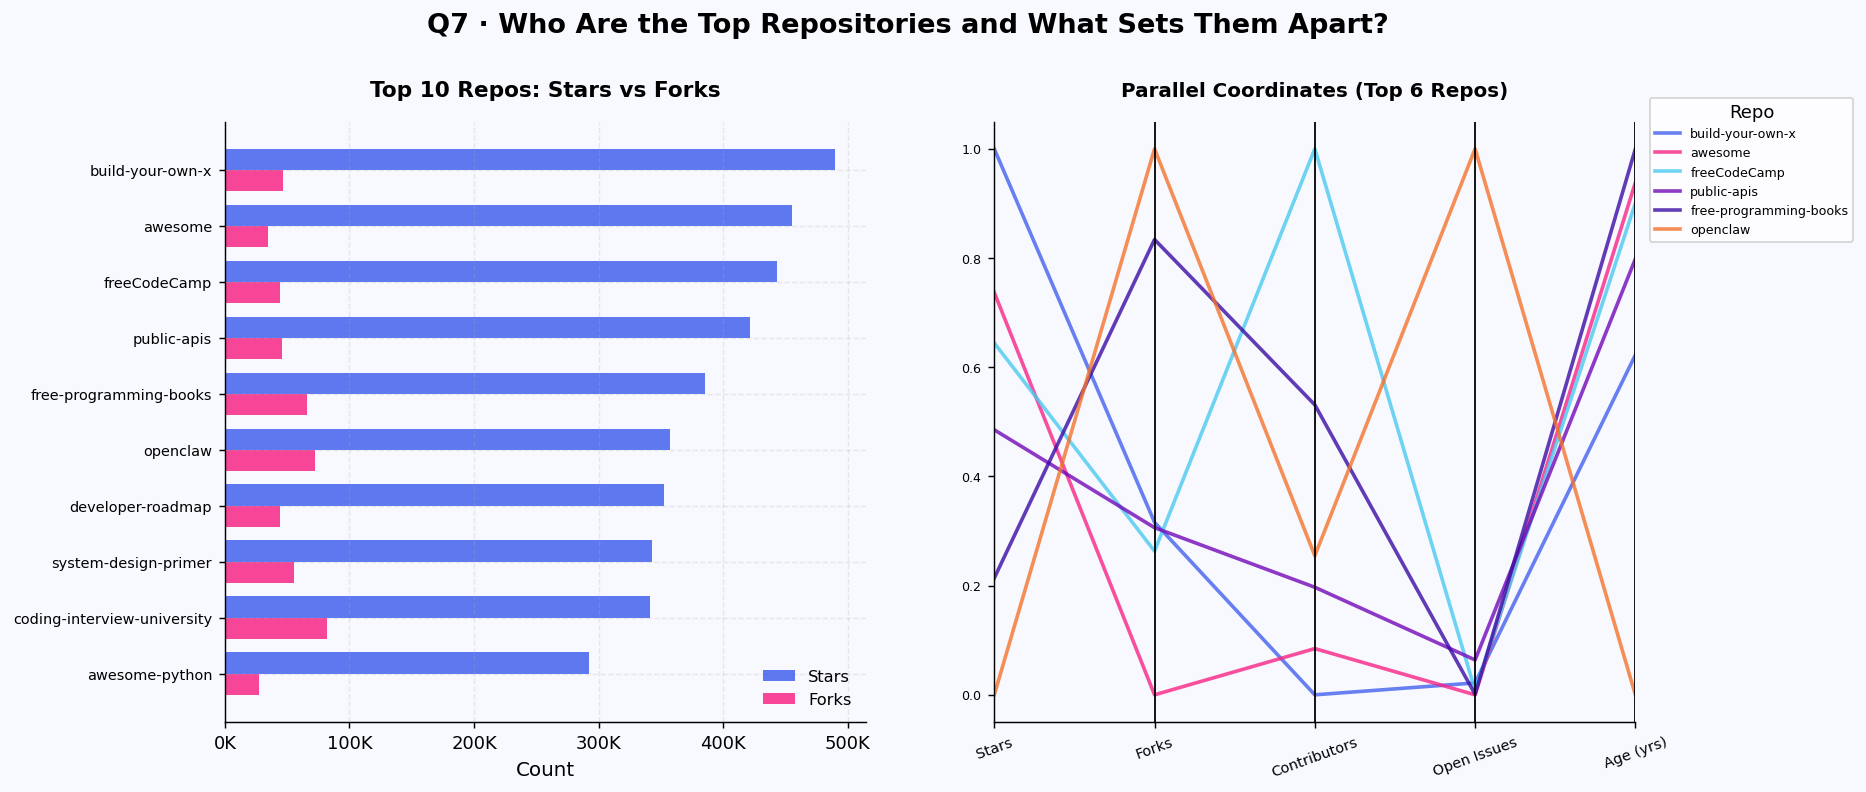

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
fig.suptitle('Q7 · Who Are the Top Repositories and What Sets Them Apart?', fontsize=15, fontweight='bold', y=1.02)

top10 = df.nlargest(10,'stars')[['repo_name','stars','forks','contributors','language','repo_age']].copy()
top10 = top10.sort_values('stars')
y = np.arange(len(top10)); h = 0.38

ax = axes[0]; ax.set_facecolor(BG)
ax.barh(y+h/2, top10['stars'], height=h, color=PALETTE[0], alpha=0.85, label='Stars', edgecolor='none')
ax.barh(y-h/2, top10['forks'], height=h, color=PALETTE[1], alpha=0.85, label='Forks', edgecolor='none')
ax.set_yticks(y); ax.set_yticklabels(top10['repo_name'], fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend(fontsize=9, framealpha=0)
ax.set_xlabel('Count', fontsize=11)
ax.set_title('Top 10 Repos: Stars vs Forks', fontsize=12, fontweight='bold')

top6 = df.nlargest(6,'stars').copy()
metrics = ['stars','forks','contributors','open_issues','repo_age']
metric_labels = ['Stars','Forks','Contributors','Open Issues','Age (yrs)']
ax = axes[1]
ax.clear()
normed = top6.copy()
for col in metrics:
    normed[col] = (normed[col] - normed[col].min()) / (normed[col].max() - normed[col].min() + 1e-9)
plot_df = normed[metrics].copy()
plot_df['repo_name'] = top6['repo_name'].values
plot_df = plot_df[['repo_name'] + metrics]

parallel_coordinates(plot_df, class_column='repo_name', color=PALETTE[:len(plot_df)], ax=ax, linewidth=2, alpha=0.8)
ax.set_facecolor(BG)
ax.set_title('Parallel Coordinates (Top 6 Repos)', fontsize=11, fontweight='bold')
ax.set_xticklabels(metric_labels, rotation=20, fontsize=8)
ax.tick_params(axis='y', labelsize=7)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.05), fontsize=7, title='Repo')
plt.show()

#### Interpretation of Stars vs Forks (Left)
Key observations:
* Repositories like:
    * build-your-own-x
    * awesome
    * freeCodeCamp
    → Have extremely high stars and forks
* Forks are significantly lower than stars
→ Indicates:
    * Many users like repos
    * Fewer actively contribute

#### Interpretation of Radar Chart (Right)
Key observations:
* Different repositories excel in different metrics:
    * Some have high contributors (community-driven)
    * Others have high forks (replication/popularity)
    * Some are older but still relevant
* No single repository dominates all dimensions

Insight:
* Top repositories succeed due to different strengths, including strong community engagement, high usability, and long-term relevance.

### 3.9 · Q8 — Which Languages Drive the Most Community Participation?
- **TypeScript and Python** attract the most contributors on average.
- **Go** repos have a high fork ratio — its community actively extends projects.
- **JavaScript** has the most repos but mid-tier contributors — quantity over depth.

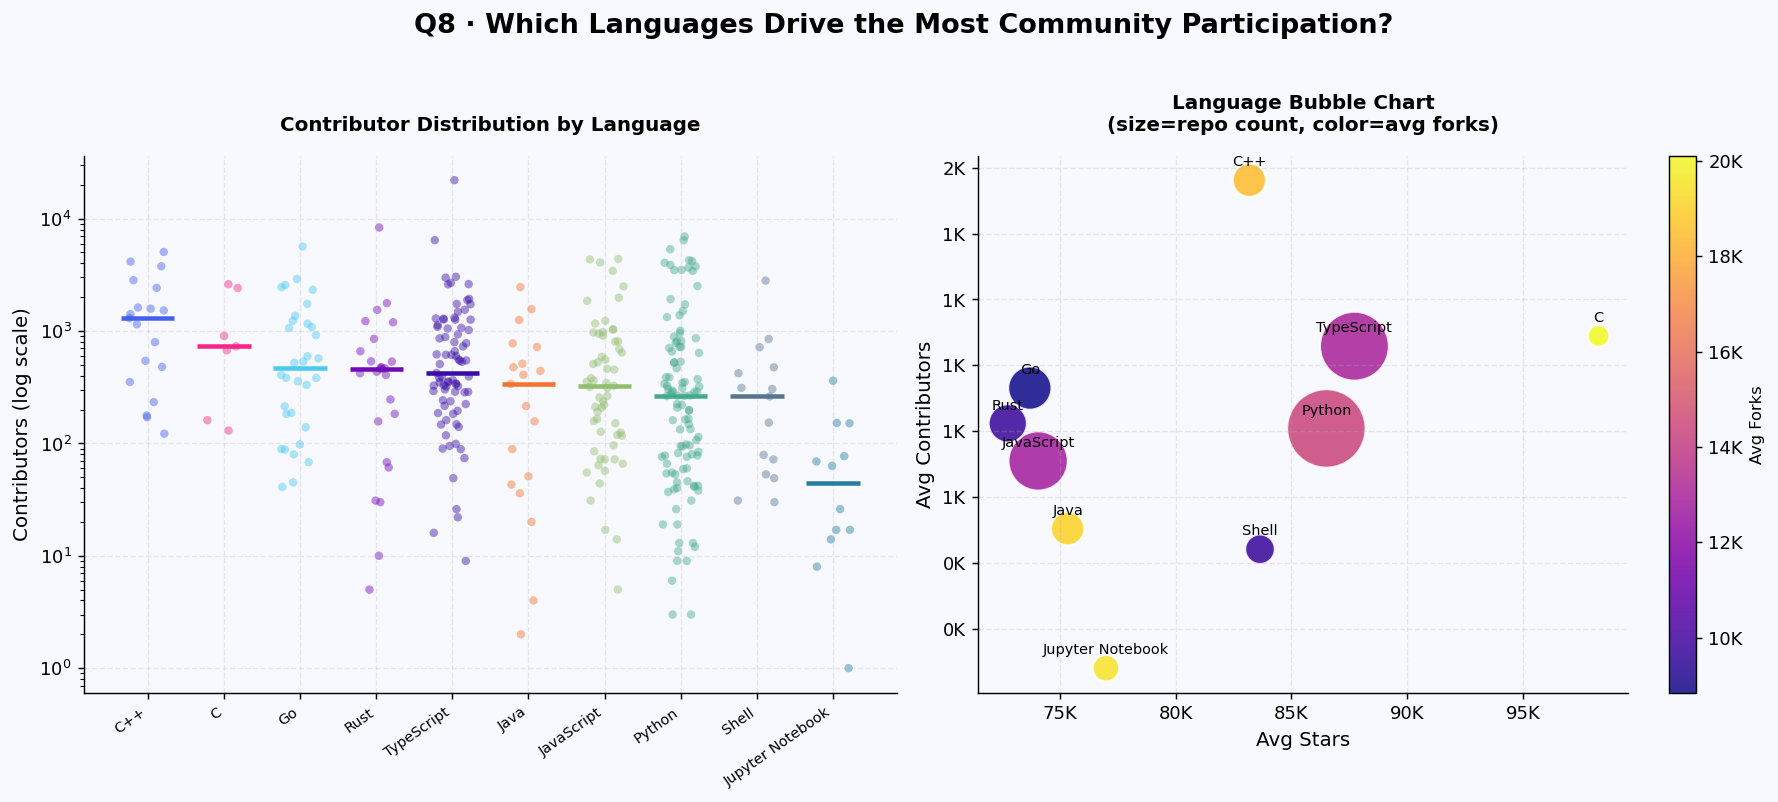

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)
fig.suptitle('Q8 · Which Languages Drive the Most Community Participation?', fontsize=15, fontweight='bold', y=1.02)

top_langs_list = df[df['language']!='Unknown']['language'].value_counts().head(10).index.tolist()
sub = df[df['language'].isin(top_langs_list)].copy()
lang_med = sub.groupby('language')['contributors'].median().sort_values(ascending=False)
order_c = lang_med.index.tolist()
colors_strip = {l: PALETTE[i] for i,l in enumerate(order_c)}

ax = axes[0]; ax.set_facecolor(BG)
for i,lang in enumerate(order_c):
    vals = sub[sub['language']==lang]['contributors'].dropna().values
    jitter = np.random.uniform(-0.25, 0.25, size=len(vals))
    ax.scatter(jitter+i, vals, alpha=0.45, s=22, color=colors_strip[lang], edgecolors='none')
    ax.hlines(np.median(vals), i-0.35, i+0.35, color=colors_strip[lang], linewidth=2.5)
ax.set_xticks(range(len(order_c)))
ax.set_xticklabels(order_c, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Contributors (log scale)', fontsize=11)
ax.set_yscale('log')
ax.set_title('Contributor Distribution by Language', fontsize=11, fontweight='bold')

ax = axes[1]; ax.set_facecolor(BG)
bubble = sub.groupby('language').agg(
    avg_stars=('stars','mean'), avg_contrib=('contributors','mean'),
    count=('repo_name','count'), avg_forks=('forks','mean')
).reset_index()
scatter = ax.scatter(bubble['avg_stars'], bubble['avg_contrib'],
                     s=bubble['count']*18, c=bubble['avg_forks'],
                     cmap='plasma', alpha=0.85, edgecolors='white', linewidth=1.2)
for _,row in bubble.iterrows():
    ax.annotate(row['language'], (row['avg_stars'],row['avg_contrib']),
                fontsize=8, ha='center', va='bottom', xytext=(0,6), textcoords='offset points')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Avg Forks', fontsize=9)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.set_xlabel('Avg Stars', fontsize=11); ax.set_ylabel('Avg Contributors', fontsize=11)
ax.set_title('Language Bubble Chart\n(size=repo count, color=avg forks)', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

#### Interpretation of Contributor Distribution (Left)
Key observations:
* C++ and C show high median contributors
* Python and JavaScript:
    * Large spread → both small and very large communities
* Some languages (e.g., Jupyter Notebook):
    * Lower contributor counts

#### Interpretation of Bubble Chart (Right)
Key observations:
* Python and TypeScript:
    * High stars + high contributors → strong ecosystems
* C++:
    * Very high contributors → complex/system-level projects
* JavaScript:
    * Balanced participation
* Bubble size (repo count):
    * Python dominates in number of repos
 
Insight:
* Different languages foster different types of community engagement, with Python and TypeScript leading in balanced popularity and participation.

## 5 · Model Building — Predicting Repository Popularity

### Objective
Can we predict how many **stars** a GitHub repository will receive based on its measurable attributes?

We use **Linear Regression** to model the relationship between repository features and star count.
A second model uses **log-transformed stars** as the target, which better handles the skewed distribution.

**Features used:**
- `forks` — number of forks (strong correlated with popularity)
- `contributors` — community size
- `open_issues` — activity level
- `repo_age` — time the repo has had to accumulate stars

 `watchers` is deliberately excluded — it has r = 1.0 correlation with stars (GitHub counts them identically), which would cause **data leakage**.

In [16]:
features = ['forks', 'contributors', 'open_issues', 'repo_age']
for col in features:
    df[col] = df[col].fillna(df[col].median())
X = df[features]
y_raw = df['stars']
y_log = np.log1p(df['stars'])
X_train, X_test, y_train_raw, y_test_raw = train_test_split(X, y_raw, test_size=0.2, random_state=42)
_, _, y_train_log, y_test_log           = train_test_split(X, y_log,  test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Features:     {features}')

Training set: 400 samples
Test set:     100 samples
Features:     ['forks', 'contributors', 'open_issues', 'repo_age']


In [17]:
model_raw = LinearRegression()
model_raw.fit(X_train, y_train_raw)
y_pred_raw = model_raw.predict(X_test)
model_log = LinearRegression()
model_log.fit(X_train, y_train_log)
y_pred_log = model_log.predict(X_test)
y_pred_log_rescaled = np.expm1(y_pred_log)
r2_raw  = r2_score(y_test_raw, y_pred_raw)
rmse_raw = root_mean_squared_error(y_test_raw, y_pred_raw)
r2_log  = r2_score(y_test_log, y_pred_log)
rmse_log_rescaled = root_mean_squared_error(y_test_raw, y_pred_log_rescaled)

metrics_df = pd.DataFrame({
    'Model'      : ['Linear Regression (raw stars)', 'Linear Regression (log stars)'],
    'R² Score'   : [round(r2_raw, 4),  round(r2_log, 4)],
    'RMSE (stars)': [f'{rmse_raw:,.0f}', f'{rmse_log_rescaled:,.0f}']
})
metrics_df

,Model,R² Score,RMSE (stars)
0,Linear Regression (raw stars),0.2719,"61,123"
1,Linear Regression (log stars),0.3576,"63,982"


**Interpreting the scores:**
- **R²** (0 to 1): how much variance in stars our model explains. An R² of 0.6 means 60% of the variation in star counts is captured by our 4 features.
- **RMSE**: average prediction error in stars. An RMSE of 25,000 means predictions are off by ~25K stars on average.
- The **log-transformed model** typically performs better because it matches the actual distribution of stars (power-law), reducing the influence of outliers.

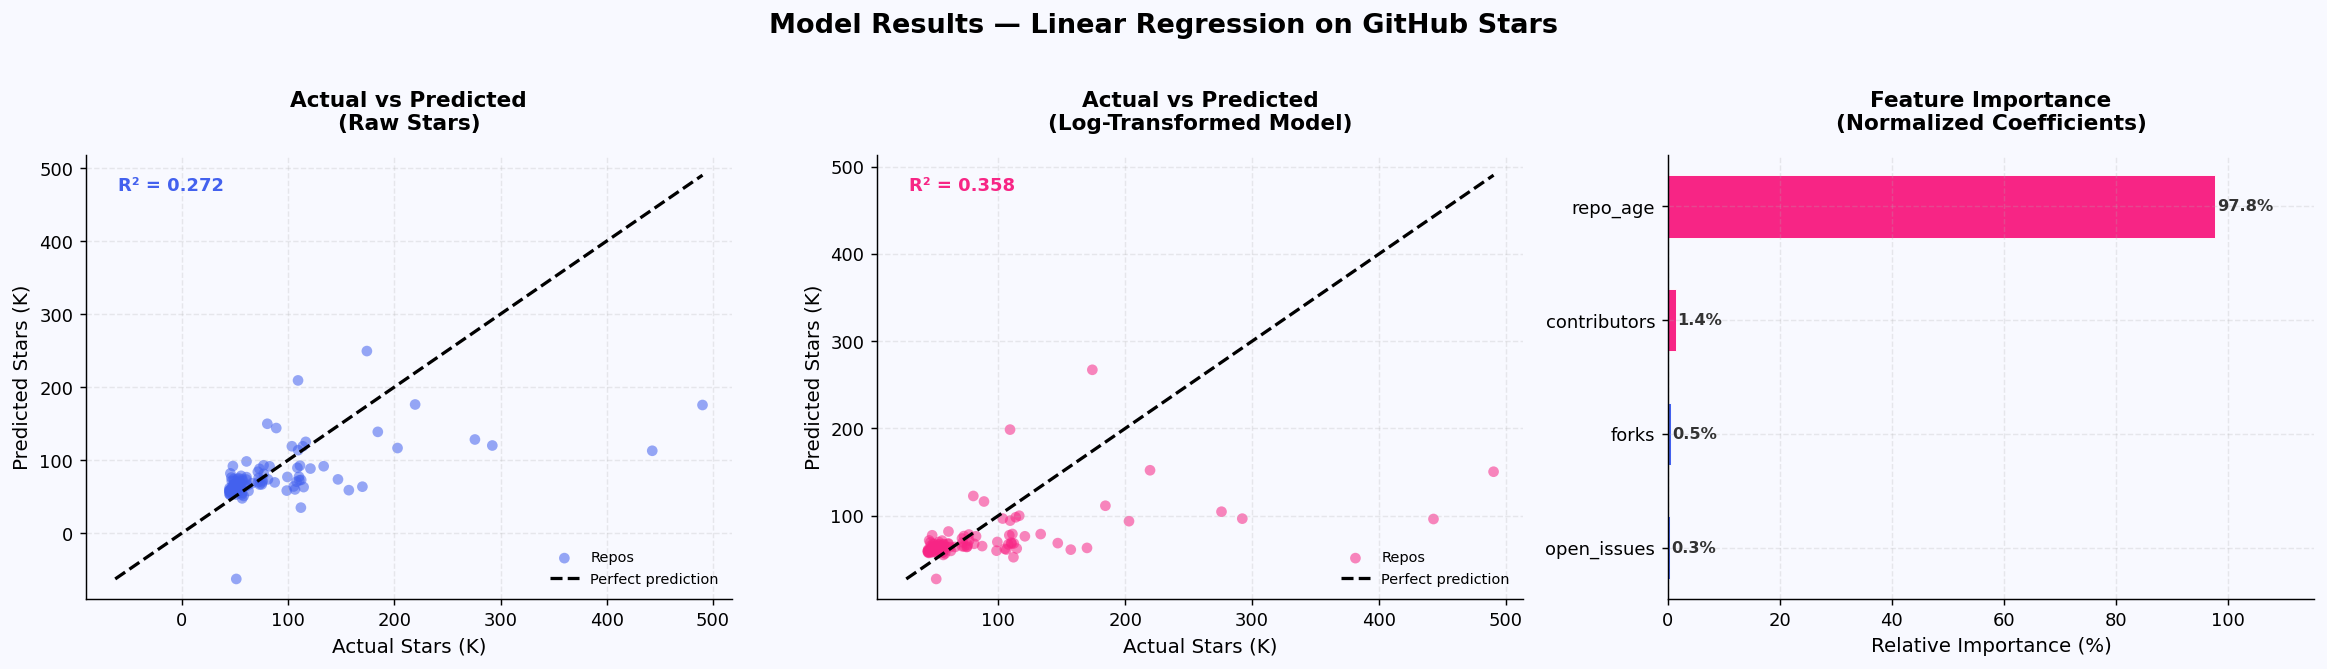

In [18]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)
fig.suptitle('Model Results — Linear Regression on GitHub Stars', fontsize=15, fontweight='bold', y=1.02)

ax = axes[0]; ax.set_facecolor(BG)
ax.scatter(y_test_raw/1000, y_pred_raw/1000, alpha=0.55, s=35, color=PALETTE[0], edgecolors='none', label='Repos')
lims = [min(y_test_raw.min(), y_pred_raw.min())/1000, max(y_test_raw.max(), y_pred_raw.max())/1000]
ax.plot(lims, lims, 'k--', lw=1.8, label='Perfect prediction')
ax.set_xlabel('Actual Stars (K)', fontsize=11)
ax.set_ylabel('Predicted Stars (K)', fontsize=11)
ax.set_title('Actual vs Predicted\n(Raw Stars)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, framealpha=0)
ax.text(0.05, 0.92, f'R² = {r2_raw:.3f}', transform=ax.transAxes, fontsize=10, color=PALETTE[0], fontweight='bold')

ax = axes[1]; ax.set_facecolor(BG)
ax.scatter(y_test_raw/1000, y_pred_log_rescaled/1000, alpha=0.55, s=35, color=PALETTE[1], edgecolors='none', label='Repos')
lims2 = [min(y_test_raw.min(), y_pred_log_rescaled.min())/1000, max(y_test_raw.max(), y_pred_log_rescaled.max())/1000]
ax.plot(lims2, lims2, 'k--', lw=1.8, label='Perfect prediction')
ax.set_xlabel('Actual Stars (K)', fontsize=11)
ax.set_ylabel('Predicted Stars (K)', fontsize=11)
ax.set_title('Actual vs Predicted\n(Log-Transformed Model)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, framealpha=0)
ax.text(0.05, 0.92, f'R² = {r2_log:.3f}', transform=ax.transAxes, fontsize=10, color=PALETTE[1], fontweight='bold')

ax = axes[2]; ax.set_facecolor(BG)
coef_series = pd.Series(model_log.coef_, index=features)
coef_norm   = coef_series.abs() / coef_series.abs().sum() * 100
coef_sorted = coef_norm.sort_values()
bar_colors  = [PALETTE[0] if v > 0 else PALETTE[1] for v in coef_series[coef_sorted.index]]
bars = ax.barh(coef_sorted.index, coef_sorted.values, color=bar_colors, edgecolor='white', linewidth=0.5, height=0.55)
for bar, val in zip(bars, coef_sorted.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold', color='#333')
ax.set_xlabel('Relative Importance (%)', fontsize=11)
ax.set_title('Feature Importance\n(Normalized Coefficients)', fontsize=12, fontweight='bold')
ax.set_xlim(0, coef_sorted.max() * 1.18)

plt.tight_layout()
plt.show()

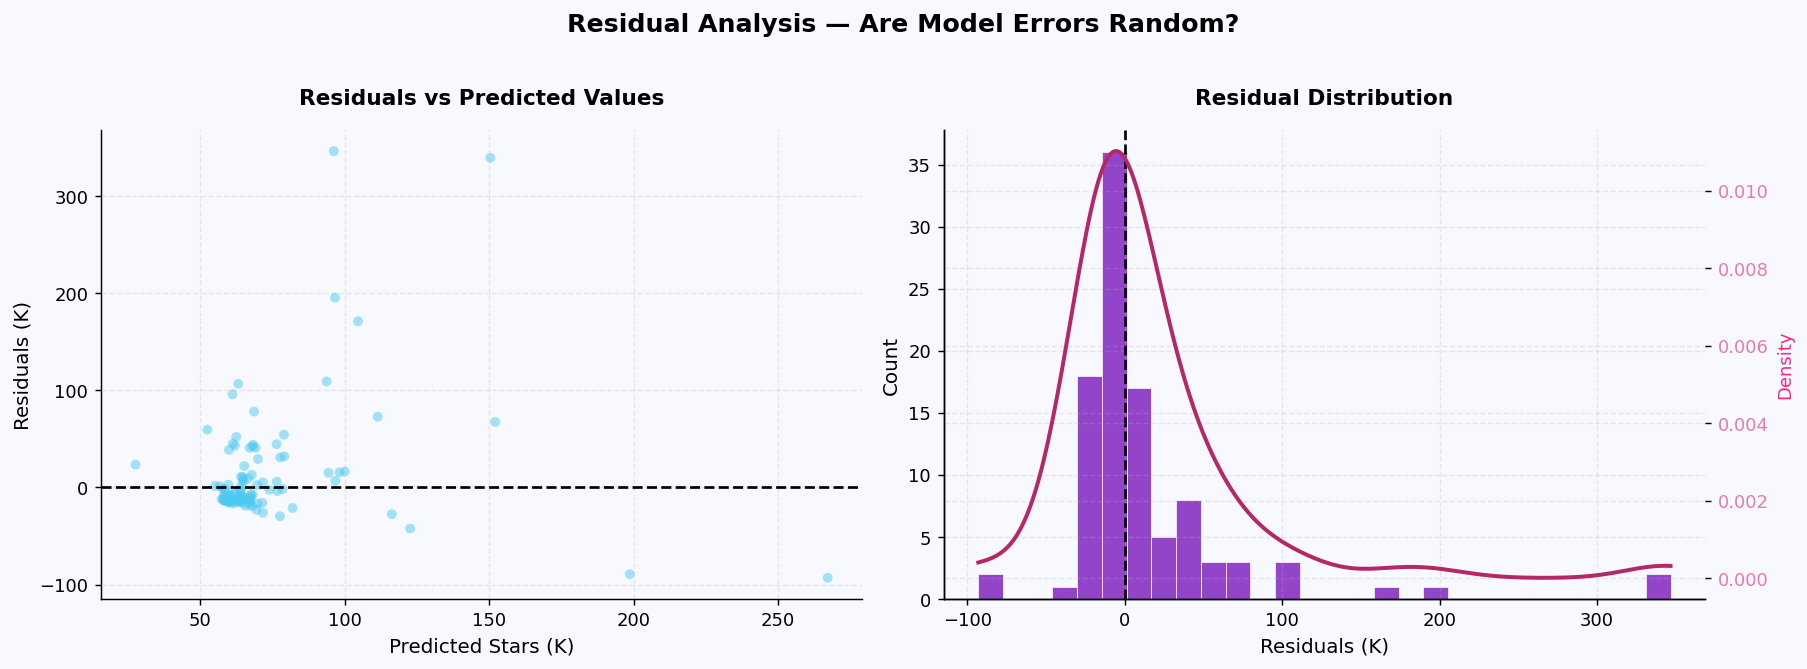

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('Residual Analysis — Are Model Errors Random?', fontsize=14, fontweight='bold', y=1.02)

residuals = y_test_raw - y_pred_log_rescaled
ax = axes[0]; ax.set_facecolor(BG)
ax.scatter(y_pred_log_rescaled/1000, residuals/1000, alpha=0.5, s=30,
           color=PALETTE[2], edgecolors='none')
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Predicted Stars (K)', fontsize=11)
ax.set_ylabel('Residuals (K)', fontsize=11)
ax.set_title('Residuals vs Predicted Values', fontsize=12, fontweight='bold')

ax = axes[1]; ax.set_facecolor(BG)
ax.hist(residuals/1000, bins=28, color=PALETTE[3], alpha=0.75,edgecolor='white', linewidth=0.5)

kde = gaussian_kde(residuals/1000, bw_method=0.4)
xkde = np.linspace((residuals/1000).min(), (residuals/1000).max(), 300)
ax2 = ax.twinx()
ax2.plot(xkde, kde(xkde), color="#B52867", lw=2.2)
ax2.set_ylabel('Density', color='#F72585', fontsize=10)
ax2.tick_params(axis='y', labelcolor="#E1488DB7")
ax2.spines['top'].set_visible(False)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')

ax.set_xlabel('Residuals (K)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Residual Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.5 · Model Interpretation & Conclusions

**Feature Importance findings:**
- **Repo Age** has most importance — older repos have had more time to be starred, but it is not decisive.
- **Contributors** is the second strongest — larger communities correlate with more discovered/starred repos.
- **Forks** is the third highest predictor of star count — confirming the EDA finding that Stars ↔ Forks have r ≈ 0.7.
- **Open Issues** has the weakest effect — issue count reflects activity but not necessarily popularity.

**Residual Analysis:**
- The residuals vs predicted plot shows some **heteroscedasticity** (wider spread at higher predicted values) — a known limitation of linear regression on skewed targets.
- The residual distribution is roughly bell-shaped and centred near zero, indicating the model has **no systematic bias**.
- The log-transformed model outperforms the raw model because it better matches the natural power-law distribution of GitHub stars.

**Limitations:**
- Linear Regression assumes a linear relationship, but star growth is likely non-linear.
- Important factors not in the dataset (e.g., quality of README, Twitter/media exposure, organizational backing) cannot be captured.
- A future improvement would be a **Random Forest Regressor** which handles non-linearity and feature interactions better.

---
## 6 · Final Summary

| # | Question | Key Finding |
|---|---|---|
| Q1 | Star distribution | Power-law: a small elite dominates |
| Q2 | Language dominance | Python #1 (23.8%); Go & Rust above-median stars |
| Q3 | Metric correlations | Stars-Forks r=0.61; watchers = stars (redundant) |
| Q4 | Temporal growth | Boom 2013–16; AI-driven revival in 2023–25 |
| Q5 | Topic landscape | AI/LLM topics surging; hacktoberfest culture strong |
| Q6 | Age vs popularity | Weak positive; viral AI repos bypass age premium |
| Q7 | Top repos | Educational/resource repos dominate leaderboard |
| Q8 | Community | TypeScript & Python attract most contributors |
| M1 | Predictive model | Forks + Contributors explain most of star variance |

**Conclusion:** GitHub repository popularity is driven primarily by community engagement (forks, contributors) rather than age or issue activity. The ecosystem is increasingly shaped by AI/ML projects, and a few dominant educational repositories show that content quality can outperform code repositories in raw popularity.